# 📦 Text Representations — Bag of Words, One-Hot & TF-IDF

**What this notebook covers:**
1. Why computers need numbers (not words)
2. One-Hot Encoding — the simplest representation (and why it fails)
3. Bag of Words (BoW) — counting words in documents
4. TF-IDF — giving words importance scores
5. Hands-on code: build all three from scratch
6. Limitations that motivate Word Embeddings

**Pre-requisites:** None. Every concept is built from the ground up.


## 1. 🤔 Why Do Computers Need Numbers?

Computers are fundamentally mathematical machines. A CPU can add, subtract, multiply and compare numbers — but it has **no concept of what "cat" means** or why "king" is related to "queen".

To apply machine learning to text, we need a way to **convert words (and documents) into numbers** that somehow capture meaning.

The central challenge:
> "How do we represent text as numbers such that **similar text produces similar numbers**?"

This is the core question of the entire Embeddings field.

### The journey we'll take:
```
"I love cats" → [0, 0, 1, 0, 1, 0, 0, 1]  ← One-hot / BoW
             → [0.3, 0.7, 0.0, ...]          ← TF-IDF
             → [0.21, -0.54, 0.87, ...]      ← Word Embeddings (next notebook)
```

Each step captures **more meaning** with **fewer limitations**.


## 2. 🔵 One-Hot Encoding

### The Idea
Build a vocabulary of all unique words you've ever seen.  
Each word becomes a vector of zeros with exactly **one 1** at the word's position.

### Step-by-Step Example

**Corpus (our entire training text):**
```
Sentence 1: "I love cats"
Sentence 2: "I love dogs"
Sentence 3: "cats are animals"
```

**Step 1 — Build the vocabulary** (sorted list of unique words):
```
Index:   0       1      2     3     4     5
Word:   "I"  "animals" "are" "cats" "dogs" "love"
```
Vocabulary size = **6 words**.

**Step 2 — Encode each word:**
```
"I"       → [1, 0, 0, 0, 0, 0]
"animals" → [0, 1, 0, 0, 0, 0]
"are"     → [0, 0, 1, 0, 0, 0]
"cats"    → [0, 0, 0, 1, 0, 0]
"dogs"    → [0, 0, 0, 0, 1, 0]
"love"    → [0, 0, 0, 0, 0, 1]
```

Each vector has exactly one `1` and all other values `0` — that's why it's called "one-hot".

---

### Why One-Hot Encoding Fails

**Problem 1 — Curse of Dimensionality:**  
A real vocabulary has 50,000–500,000 words. Each word needs a vector with 50,000 or 500,000 dimensions — mostly zeros. This is massively wasteful.

**Problem 2 — No Semantic Relationship:**  
Every pair of word vectors has **zero dot product** (they're orthogonal):
$$\text{"cats"} \cdot \text{"dogs"} = [0,0,0,1,0,0] \cdot [0,0,0,0,1,0] = 0$$
$$\text{"cats"} \cdot \text{"love"} = [0,0,0,1,0,0] \cdot [0,0,0,0,0,1] = 0$$

**cats and dogs have exactly the same similarity as cats and love = 0.**  
The encoding has **no notion that cats and dogs are both animals.**

**Problem 3 — Fixed Vocabulary:**  
If you encounter a word not in your vocabulary ("puppy"), you have no representation for it — it becomes `[0,0,0,...,0]` (the unknown token).

> **Key point:** One-hot encoding treats every word as completely unrelated to every other word. But "good" and "great" should be close; "cat" and "automobile" should be far apart. One-hot can't capture this.


Vocabulary: ['animals', 'are', 'cats', 'dogs', 'i', 'love']
Vocabulary size: 6

One-Hot Vectors:
Word          animals       are      cats      dogs         i      love
----------------------------------------------------------------------
cats                0         0         1         0         0         0
dogs                0         0         0         1         0         0
love                0         0         0         0         0         1
animals             1         0         0         0         0         0

Cosine similarities between one-hot vectors:
  sim(cats    , dogs    ) = 0.0000  ← ALWAYS 0!
  sim(cats    , love    ) = 0.0000  ← ALWAYS 0!
  sim(cats    , animals ) = 0.0000  ← ALWAYS 0!
  sim(dogs    , animals ) = 0.0000  ← ALWAYS 0!

Problem: 'cats' and 'dogs' are just as similar as 'cats' and 'love' (both = 0)
One-hot encodes NO semantic information whatsoever.


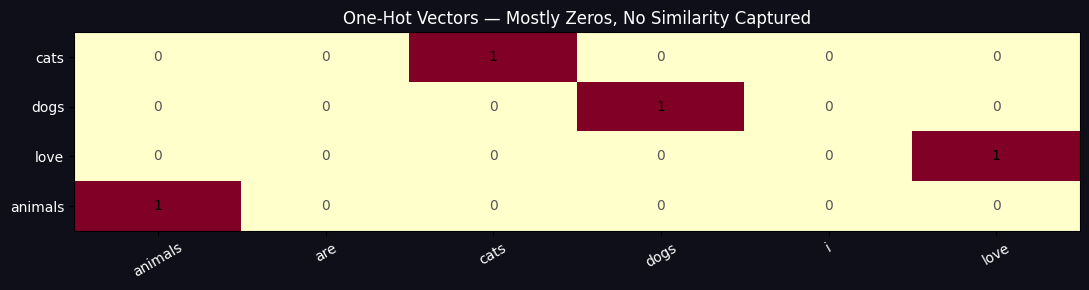

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ── Build vocabulary from a tiny corpus ──
corpus = [
    "I love cats",
    "I love dogs",
    "cats are animals",
    "dogs are animals"
]

# Step 1: Build vocabulary
all_words = []
for sent in corpus:
    all_words.extend(sent.lower().split())
vocab = sorted(set(all_words))
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

print("Vocabulary:", vocab)
print(f"Vocabulary size: {len(vocab)}")
print()

# Step 2: One-hot encoding function
def one_hot(word, word2idx):
    vec = np.zeros(len(word2idx), dtype=int)
    if word in word2idx:
        vec[word2idx[word]] = 1
    return vec

# Encode a few words
words_to_show = ["cats", "dogs", "love", "animals"]
vectors = {w: one_hot(w, word2idx) for w in words_to_show}

print("One-Hot Vectors:")
print(f"{'Word':<12}", "  ".join(f"{w:>8}" for w in vocab))
print("-" * 70)
for word, vec in vectors.items():
    print(f"{word:<12}", "  ".join(f"{v:>8}" for v in vec))

# ── Show why cosine similarity is always 0 ──
print()
from numpy.linalg import norm
def cosine_sim(a, b):
    if norm(a) == 0 or norm(b) == 0:
        return 0.0
    return np.dot(a, b) / (norm(a) * norm(b))

print("Cosine similarities between one-hot vectors:")
pairs = [("cats","dogs"), ("cats","love"), ("cats","animals"), ("dogs","animals")]
for w1, w2 in pairs:
    sim = cosine_sim(vectors[w1], vectors[w2])
    print(f"  sim({w1:8s}, {w2:8s}) = {sim:.4f}  ← {'same' if w1==w2 else 'ALWAYS 0!'}")

print()
print("Problem: 'cats' and 'dogs' are just as similar as 'cats' and 'love' (both = 0)")
print("One-hot encodes NO semantic information whatsoever.")

# ── Visualise: sparse vectors ──
fig, ax = plt.subplots(figsize=(11, 3))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#13131f')
matrix = np.array([vectors[w] for w in words_to_show])
ax.imshow(matrix, cmap='YlOrRd', aspect='auto')
ax.set_yticks(range(len(words_to_show))); ax.set_yticklabels(words_to_show, color='white')
ax.set_xticks(range(len(vocab))); ax.set_xticklabels(vocab, color='white', rotation=30)
ax.set_title("One-Hot Vectors — Mostly Zeros, No Similarity Captured", color='white')
for i in range(len(words_to_show)):
    for j in range(len(vocab)):
        ax.text(j, i, str(matrix[i,j]), ha='center', va='center',
                color='black' if matrix[i,j] else '#555', fontsize=10)
plt.tight_layout()
# plt.savefig('llm_basic/assets/01_one_hot.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


## 3. 🛍️ Bag of Words (BoW)

### The Idea
Instead of encoding one word at a time, encode an **entire document** as a vector.  
Each position in the vector represents a word in the vocabulary.  
The value at that position = the **count** of how many times that word appears in the document.

The word "Bag" in "Bag of Words" reflects the key limitation: we throw all words into a bag and **lose the order**. "I love cats" and "cats love I" would produce the same vector.

### Step-by-Step Example

**Vocabulary (from the same corpus as before):**
```
Index:   0     1        2     3      4      5
Word:   "I" "animals" "are" "cats" "dogs" "love"
```

**Encoding each sentence:**
```
"I love cats"    → [1, 0, 0, 1, 0, 1]    (I×1, love×1, cats×1)
"I love dogs"    → [1, 0, 0, 0, 1, 1]    (I×1, love×1, dogs×1)
"cats are animals" → [0, 1, 1, 1, 0, 0]  (animals×1, are×1, cats×1)
```

### BoW Limitations

**1. Word Order Lost:** "The cat bit the dog" and "The dog bit the cat" produce the same BoW vector — but have opposite meanings.

**2. Common Words Dominate:** Words like "the", "a", "is" appear in every document and get high counts, drowning out the meaningful words like "excellent" or "terrible".

**3. No Semantics:** "I hate this movie" and "I love this movie" differ by only one word, but BoW can't capture emotional polarity without extra processing.

**4. Vocabulary Mismatch:** Same sparsity and fixed-vocabulary problems as one-hot.

> BoW is still useful for simple tasks! It powered email spam filters and early text classifiers effectively. But for semantic understanding, we need more.

### The Document-Term Matrix
When we encode an entire dataset of documents, we get a **Document-Term Matrix (DTM)**:
- Rows = Documents
- Columns = Vocabulary words  
- Value = word count (or binary presence)

For large corpora with 50,000 word vocabularies, this matrix is >99.9% zeros — extremely sparse.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

corpus = [
    "I love cats",
    "I love dogs",
    "cats are animals",
    "dogs are animals",
    "I love animals",
]

# Build vocabulary (sorted for determinism)
all_words = []
for sent in corpus:
    all_words.extend(sent.lower().split())

# Remove stopwords for demo (show both)
stop_words = set()  # keep all words for this demo
vocab = sorted(set(all_words) - stop_words)
word2idx = {w: i for i, w in enumerate(vocab)}
V = len(vocab)

print(f"Vocabulary ({V} words): {vocab}")
print()

# ── Build Document-Term Matrix ──
DTM = np.zeros((len(corpus), V), dtype=int)
for doc_idx, sent in enumerate(corpus):
    counts = Counter(sent.lower().split())
    for word, cnt in counts.items():
        DTM[doc_idx, word2idx[word]] = cnt

print("Document-Term Matrix (BoW):")
print(f"{'Document':<30}", "".join(f"{w:>9}" for w in vocab))
print("-" * (30 + 9*V))
for i, (sent, row) in enumerate(zip(corpus, DTM)):
    print(f"Doc{i+1}: {sent:<23}", "".join(f"{v:>9}" for v in row))

# ── Visualise DTM as heatmap ──
fig, ax = plt.subplots(figsize=(12, 4))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#13131f')
im = ax.imshow(DTM, cmap='Blues', aspect='auto')
ax.set_xticks(range(V)); ax.set_xticklabels(vocab, color='white', rotation=30, ha='right')
ax.set_yticks(range(len(corpus)))
ax.set_yticklabels([f'Doc{i+1}: "{s}"' for i, s in enumerate(corpus)],
                   color='white', fontsize=8)
ax.set_title("Bag of Words — Document-Term Matrix", color='white')
for i in range(len(corpus)):
    for j in range(V):
        ax.text(j, i, str(DTM[i,j]), ha='center', va='center',
                color='black' if DTM[i,j] > 0 else '#555', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8, label='Word count')
plt.tight_layout()
plt.savefig('llm_basic/assets/01_bow_matrix.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

# ── Show the word-order problem ──
print()
print("Word Order Problem:")
s1 = "the cat bit the dog"
s2 = "the dog bit the cat"
vocab2 = sorted(set(s1.split() + s2.split()))
w2i = {w: i for i, w in enumerate(vocab2)}
v1 = np.zeros(len(vocab2), dtype=int)
v2 = np.zeros(len(vocab2), dtype=int)
for w in s1.split(): v1[w2i[w]] += 1
for w in s2.split(): v2[w2i[w]] += 1
print(f"  '{s1}' → {v1.tolist()}")
print(f"  '{s2}' → {v2.tolist()}")
print(f"  Are they identical? {np.array_equal(v1, v2)}  ← Same vector, opposite meaning!")


## 4. 📊 TF-IDF — Term Frequency × Inverse Document Frequency

### The Problem with Raw Counts
Consider a corpus of 1000 movie reviews. The word **"the"** appears thousands of times in every review.  
The word **"masterpiece"** appears only in 5 reviews, but when it does, it's highly informative.

Raw BoW counts give "the" a higher number than "masterpiece" — exactly backwards from what we want.

**Solution:** Weight each word by both how often it appears in THIS document (TF) and how rare it is across ALL documents (IDF).

---

### Term Frequency (TF)

How often does word $w$ appear in document $d$?

$$TF(w, d) = \frac{\text{count of } w \text{ in } d}{\text{total words in } d}$$

This normalises for document length — a 1000-word document would otherwise dominate over a 100-word one.

**Example:** In "I love cats and love dogs" (6 words):
$$TF(\text{"love"}, d) = \frac{2}{6} = 0.333$$
$$TF(\text{"cats"}, d) = \frac{1}{6} = 0.167$$

---

### Inverse Document Frequency (IDF)

How rare is word $w$ across all $N$ documents?  
Let $df(w)$ = number of documents containing $w$.

$$IDF(w) = \log\left(\frac{N}{df(w)}\right)$$

The **log** prevents very rare words from having astronomically large IDF values, and keeps the scale manageable.

**Intuition:**
- "the" appears in every document → $IDF = \log(N/N) = \log(1) = 0.0$ → score is completely suppressed!
- "masterpiece" appears in 5 of 1000 docs → $IDF = \log(1000/5) = \log(200) \approx 5.3$ → high penalisation
- A word appearing in half the docs → $IDF = \log(2) \approx 0.69$ → moderate weight

---

### TF-IDF Score

Combine them: 
$$TF\text{-}IDF(w, d) = TF(w, d) \times IDF(w)$$

**What this achieves:**
- Words frequent in THIS document AND rare across ALL documents get a high score (e.g., "masterpiece" in a praising review)
- Common words like "the" get score ≈ 0 (high TF but IDF ≈ 0)
- Words in every document get score = 0 (killed by IDF)

---

### Smoothed IDF (sklearn convention)
To avoid division-by-zero for words in every document:
$$IDF(w) = \log\left(\frac{N + 1}{df(w) + 1}\right) + 1$$

The `+1` in numerator/denominator prevents zero IDF. The outer `+1` prevents the score being zero even when df=N.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import math

corpus = [
    "the cat sat on the mat",
    "the dog sat on the log",
    "cats and dogs are great animals",
    "the masterpiece film was brilliant and great",
    "a brilliant and masterpiece performance",
]

# Build vocabulary
all_words = [w for sent in corpus for w in sent.lower().split()]
vocab = sorted(set(all_words))
word2idx = {w: i for i, w in enumerate(vocab)}
V = len(vocab)
N = len(corpus)

# ── Compute TF ──
def compute_tf(doc_tokens, vocab):
    counts = Counter(doc_tokens)
    total  = len(doc_tokens)
    return {w: counts[w]/total for w in vocab}

# ── Compute IDF (vanilla) ──
def compute_idf(corpus_tokens_list, vocab):
    df = {}
    for word in vocab:
        df[word] = sum(1 for doc in corpus_tokens_list if word in doc)
    N = len(corpus_tokens_list)
    return {w: math.log((N+1)/(df[w]+1)) + 1 for w in vocab}

all_tokens   = [sent.lower().split() for sent in corpus]
idf          = compute_idf(all_tokens, vocab)

# Build TF-IDF matrix
tfidf_matrix = np.zeros((N, V))
for i, tokens in enumerate(all_tokens):
    tf = compute_tf(tokens, vocab)
    for j, word in enumerate(vocab):
        tfidf_matrix[i, j] = tf[word] * idf[word]

# ── Print TF-IDF for interesting words ──
print("IDF values (higher = rarer across corpus):")
focus_words = ["the", "sat", "great", "masterpiece", "brilliant", "animals"]
for word in focus_words:
    if word in word2idx:
        df_count = sum(1 for doc in all_tokens if word in doc)
        print(f"  '{word:<12}': IDF={idf[word]:.4f}  (in {df_count}/{N} docs)")

print()
print("TF-IDF scores for doc 3 (masterpiece film):")
doc_idx = 3
doc_tfidf = {vocab[j]: tfidf_matrix[doc_idx, j] for j in range(V) if tfidf_matrix[doc_idx,j]>0}
for word, score in sorted(doc_tfidf.items(), key=lambda x: -x[1]):
    print(f"  '{word:<15}': {score:.4f}")

# ── Visualise top words per document ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#0f0f1a')

# Left: full TF-IDF heatmap (subset of words for clarity)
focus_vocab = ["the", "cat", "dog", "masterpiece", "brilliant", "great", "sat", "animals"]
focus_idx   = [word2idx[w] for w in focus_vocab if w in word2idx]
sub_matrix  = tfidf_matrix[:, focus_idx]
focus_vocab_clean = [vocab[i] for i in focus_idx]

ax = axes[0]
ax.set_facecolor('#13131f')
im = ax.imshow(sub_matrix, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(focus_idx))); ax.set_xticklabels(focus_vocab_clean, color='white', rotation=30, ha='right')
ax.set_yticks(range(N))
ax.set_yticklabels([f"Doc{i+1}" for i in range(N)], color='white')
ax.set_title("TF-IDF Heatmap
(brighter = more important)", color='white')
for i in range(N):
    for j in range(len(focus_idx)):
        v = sub_matrix[i,j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                color='black' if v > 0.15 else '#888', fontsize=8)
plt.colorbar(im, ax=ax, shrink=0.8)

# Right: IDF values bar chart
ax2 = axes[1]
ax2.set_facecolor('#13131f')
idf_vals = [idf[w] for w in focus_vocab_clean]
colors   = ['#ff6b6b' if v < 1.5 else '#4ecdc4' for v in idf_vals]
bars     = ax2.barh(range(len(focus_vocab_clean)), idf_vals, color=colors)
ax2.set_yticks(range(len(focus_vocab_clean)))
ax2.set_yticklabels(focus_vocab_clean, color='white')
ax2.set_xlabel('IDF score', color='#aaa')
ax2.set_title('IDF Scores
Red=common, Teal=rare/informative', color='white')
ax2.tick_params(colors='#aaa')
ax2.axvline(x=1.5, color='#fdcb6e', ls='--', lw=1.5, label='threshold')
ax2.legend(fontsize=9, labelcolor='white', facecolor='#1a1a2e')
for sp in ax2.spines.values(): sp.set_color('#333')

plt.suptitle("TF-IDF — Words Weighted by Importance", color='white', fontsize=13)
plt.tight_layout()
plt.savefig('llm_basic/assets/01_tfidf.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

# ── Compare with sklearn ──
print()
print("Verification against sklearn TfidfVectorizer:")
from sklearn.feature_extraction.text import TfidfVectorizer
vec = TfidfVectorizer()
X = vec.fit_transform(corpus)
print("  sklearn TF-IDF shape:", X.shape)
print("  Top 5 features for Doc 4 ('masterpiece film...'):")
doc4_arr = X[3].toarray()[0]
top5 = sorted(zip(vec.get_feature_names_out(), doc4_arr), key=lambda x:-x[1])[:5]
for word, score in top5:
    print(f"    '{word}': {score:.4f}")


## 5. 🌉 Limitations Summary & The Bridge to Word Embeddings

### Comparison Table

| Property | One-Hot | BoW | TF-IDF |
|---|---|---|---|
| **Representation unit** | Single word | Entire document | Entire document |
| **Captures word meaning?** | ❌ No | ❌ No | ❌ No |
| **Captures word order?** | N/A | ❌ No | ❌ No |
| **Handles rare words?** | ❌ Unknown token | ❌ No weight | ✅ Rewards rare words |
| **Handles common words?** | ❌ Equal to all | ❌ High count | ✅ IDF suppresses |
| **Dimensionality** | vocab size (50K+) | vocab size (50K+) | vocab size (50K+) |
| **Sparsity** | 99.99% zeros | 95–99% zeros | 95–99% zeros |
| **Semantic similarity** | ❌ All = 0 | ❌ Very limited | ⚠️ Slightly better |
| **Context-aware?** | ❌ | ❌ | ❌ |

---

### The Fundamental Gap

All three methods share a critical flaw: **they can't capture semantic meaning**.

Consider these two sentences:
- "The movie was **excellent**"  
- "The movie was **wonderful**"

In any of the above representations, "excellent" and "wonderful" are treated as completely unrelated tokens. A classifier that learned "excellent" = positive would have to learn separately that "wonderful" = positive.

**What we really want:**
$$\text{similarity}(\text{"excellent"}, \text{"wonderful"}) \approx 0.9$$
$$\text{similarity}(\text{"excellent"}, \text{"terrible"}) \approx -0.5$$
$$\text{similarity}(\text{"king"} - \text{"man"} + \text{"woman"}, \text{"queen"}) \approx 0.95$$

To achieve this, we need **dense, low-dimensional vectors that are learned from context**.  
That's exactly what **Word2Vec** (the next notebook) provides.

### Key Insight: The Distributional Hypothesis
> "You shall know a word by the company it keeps." — J.R. Firth, 1957

Words that appear in similar contexts tend to have similar meanings.  
- "cat" and "dog" both appear near "pet", "fur", "bark"/"meow", "owner", "feed"  
- This co-occurrence pattern is the signal that Word2Vec learns from

The next notebook — `02_word2vec.ipynb` — shows exactly how Word2Vec exploits this signal.


## 6. 🎯 Interview Q&A

**Q1: What's the difference between BoW and TF-IDF?**
> BoW simply counts word occurrences. TF-IDF multiplies the normalised count (TF) by a penalty for words that appear in many documents (IDF). Result: common words like "the" get near-zero scores, while domain-specific words get high scores. TF-IDF is always preferred over raw BoW for most text classification tasks.

---

**Q2: Why does IDF use a logarithm?**
> Without the log, rare words would have astronomical weights. If "masterpiece" appears in 1 of 1,000 docs, the raw ratio is 1000 — dominating all other signals. Log compresses this: log(1000) ≈ 6.9, which is informative but not overwhelming. The log also has a nice property: if a word appears in all documents, IDF = log(1) = 0, perfectly suppressing it.

---

**Q3: What is the cosine similarity problem with one-hot vectors?**
> Two different one-hot vectors always have a dot product of exactly 0 because they have their single '1' at different positions. Since cosine similarity = dot product / (product of norms) = 0 / (1 × 1) = 0, every pair of different words has identical similarity: zero. This means the representation carries no semantic information at all.

---

**Q4: Can TF-IDF capture that "good" and "great" are related?**
> No. TF-IDF assigns each word an independent importance score, but doesn't place words in a geometric space where proximity reflects meaning. "good" and "great" are treated as unrelated dimensions in the vocabulary space. This is why we move to Word Embeddings, which learn a shared, dense vector space where semantically related words cluster together.

---

**Q5: When is TF-IDF still useful today?**
> TF-IDF remains useful in: (1) document retrieval and search, especially BM25 (an improvement on TF-IDF), (2) keyword extraction, (3) as a fast baseline for text classification when neural models are too expensive, (4) hybrid search systems that combine TF-IDF (lexical) with vector search (semantic) — this is called hybrid retrieval, widely used in modern RAG systems.
